In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


In [2]:
df = pd.read_csv("/content/car data.csv")

# Display first 5 rows
print("FIRST 5 ROWS OF DATASET:\n")
print(df.head())


FIRST 5 ROWS OF DATASET:

  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  


In [3]:
print("\nDATASET INFORMATION:\n")
print(df.info())

print("\nMISSING VALUES:\n")
print(df.isnull().sum())



DATASET INFORMATION:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB
None

MISSING VALUES:

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64


In [4]:
# Remove missing values if any
df.dropna(inplace=True)

# Display cleaned data
print("\nCLEANED DATA:\n")
print(df.head())



CLEANED DATA:

  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  


In [7]:
label_encoder = LabelEncoder()

categorical_columns = [
    'Car_Name',
    'Fuel_Type',
    'Selling_type', # Corrected from 'Seller_Type'
    'Transmission'
]

for column in categorical_columns:
    df[column] = label_encoder.fit_transform(df[column])

In [8]:
X = df.drop('Selling_Price', axis=1)

# Target variable
y = df['Selling_Price']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Data Size:", len(X_train))
print("Testing Data Size:", len(X_test))


Training Data Size: 240
Testing Data Size: 61


In [10]:
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

print("\nMODEL TRAINED SUCCESSFULLY!")



MODEL TRAINED SUCCESSFULLY!


In [11]:
y_pred = model.predict(X_test)

In [12]:
mae = mean_absolute_error(y_test, y_pred)

# Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

# Root Mean Squared Error
rmse = np.sqrt(mse)

# R2 Score
r2 = r2_score(y_test, y_pred)

print("\n===================================")
print("MODEL EVALUATION")
print("===================================")

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)


MODEL EVALUATION
Mean Absolute Error: 1.2147329896540084
Mean Squared Error: 3.537020423742584
Root Mean Squared Error: 1.8806967920806863
R2 Score: 0.8464540623821766


In [13]:
comparison = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': y_pred
})

print("\nACTUAL VS PREDICTED PRICES:\n")
print(comparison.head())


ACTUAL VS PREDICTED PRICES:

     Actual Price  Predicted Price
177          0.35         2.974919
289         10.11         8.326128
228          4.95         6.016123
198          0.15        -1.381724
60           6.95         9.279406


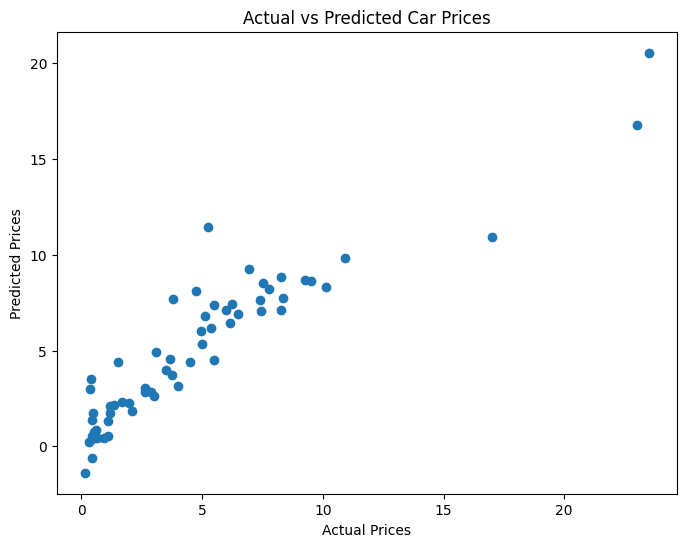

In [14]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted Car Prices")

plt.show()

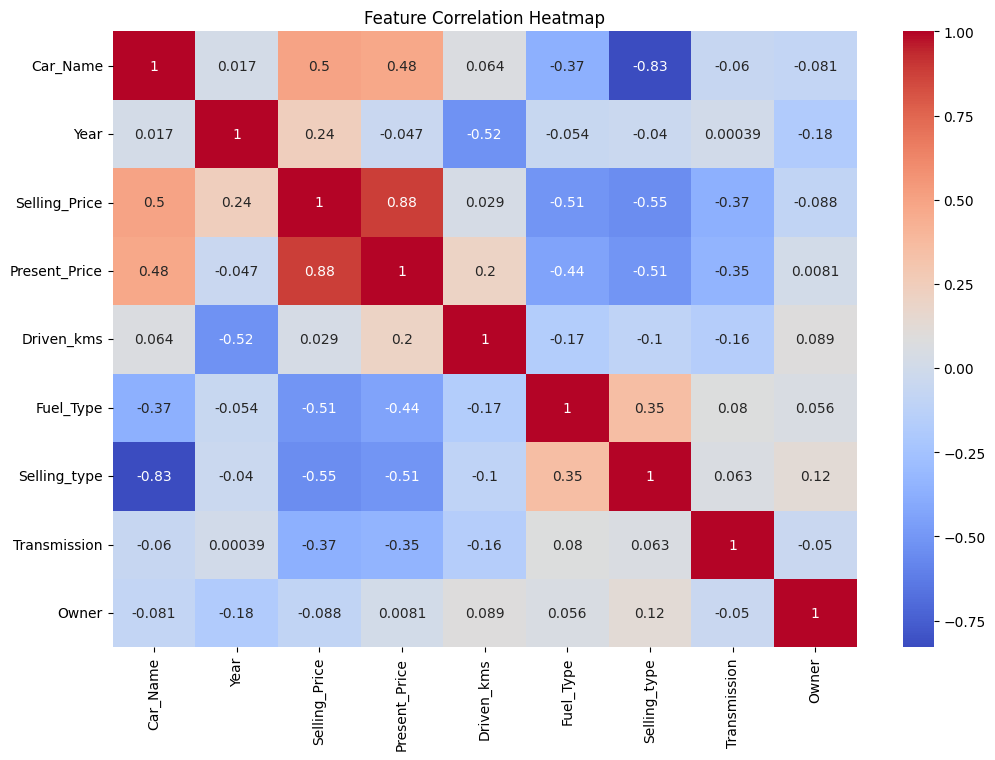

In [15]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")

plt.show()


In [16]:

new_car = [[
    50,     # Car_Name (encoded)
    2018,   # Year
    7.0,    # Present_Price
    50000,  # Kms_Driven
    1,      # Fuel_Type
    0,      # Seller_Type
    0,      # Transmission
    0       # Owner
]]

predicted_price = model.predict(new_car)

print("\n===================================")
print("NEW CAR PRICE PREDICTION")
print("===================================")

print("Predicted Car Price:", predicted_price[0])


NEW CAR PRICE PREDICTION
Predicted Car Price: 8.961019806936179


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [17]:
print("\n===================================")
print("PROJECT INSIGHTS")
print("===================================")

print("""
1. Car price depends on multiple factors such as:
   - Brand
   - Mileage
   - Fuel type
   - Transmission
   - Manufacturing year

2. Regression models can estimate car prices accurately.

3. Higher R2 Score means better model performance.

4. Machine learning is widely used in:
   - Online car marketplaces
   - Insurance systems
   - Vehicle valuation systems

5. Data preprocessing is important before training models.
""")


PROJECT INSIGHTS

1. Car price depends on multiple factors such as:
   - Brand
   - Mileage
   - Fuel type
   - Transmission
   - Manufacturing year

2. Regression models can estimate car prices accurately.

3. Higher R2 Score means better model performance.

4. Machine learning is widely used in:
   - Online car marketplaces
   - Insurance systems
   - Vehicle valuation systems

5. Data preprocessing is important before training models.

